In [5]:
from GraphRicciCurvature.multiHopORC import MultiOllivierRicci

In [1]:
import networkit as nk
from networkit import nxadapter
import pandas as pd
import networkx as nx
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
cora = nx.read_gexf("data/cora_rf_sinkhorn_e2_20.gexf", node_type=None, relabel=False, version='1.2draft')
# Clean up the pre-computed Ricci curvature and Ricci flow to start from the begining.
def clean_graph(G):
    for n1, n2 in G.edges():
        del G[n1][n2]["ricciCurvature"]
        del G[n1][n2]["original_RC"]
        G[n1][n2]["weight"]=1
    for n in G.nodes():
        del G.nodes[n]["ricciCurvature"]

In [3]:
clean_graph(cora)
cora.edges(data=True)

EdgeDataView([('74700', '23069', {'id': '0', 'weight': 1}), ('74700', '134307', {'id': '1', 'weight': 1}), ('684986', '684972', {'id': '2', 'weight': 1}), ('684986', '395553', {'id': '3', 'weight': 1}), ('684986', '4330', {'id': '4', 'weight': 1}), ('127940', '1114364', {'id': '5', 'weight': 1}), ('127940', '243274', {'id': '6', 'weight': 1}), ('127940', '416964', {'id': '7', 'weight': 1}), ('127940', '430329', {'id': '8', 'weight': 1}), ('686015', '27623', {'id': '9', 'weight': 1}), ('686015', '75674', {'id': '10', 'weight': 1}), ('686015', '27627', {'id': '11', 'weight': 1}), ('686015', '28254', {'id': '12', 'weight': 1}), ('23448', '19621', {'id': '13', 'weight': 1}), ('23448', '1365', {'id': '14', 'weight': 1}), ('23448', '123825', {'id': '15', 'weight': 1}), ('131117', '400473', {'id': '16', 'weight': 1}), ('131117', '29492', {'id': '17', 'weight': 1}), ('131117', '152219', {'id': '18', 'weight': 1}), ('131117', '212930', {'id': '19', 'weight': 1}), ('144330', '63486', {'id': '20'

In [7]:
def show_results(G, curvature="ricciCurvature"):

    # Print the first five results
    print("cora, first 5 edges: ")
    for n1,n2 in list(G.edges())[:5]:
        print("Ricci curvature of edge (%s,%s) is %f" % (n1 ,n2, G[n1][n2][curvature]))

    # Plot the histogram of Ricci curvatures
    plt.subplot(2, 1, 1)
    ricci_curvtures = nx.get_edge_attributes(G, curvature).values()
    plt.hist(ricci_curvtures,bins=20)
    plt.xlabel('Ricci curvature')
    plt.title("Histogram of Ricci Curvatures (cora)")

    # Plot the histogram of edge weights
    plt.subplot(2, 1, 2)
    weights = nx.get_edge_attributes(G, "weight").values()
    plt.hist(weights,bins=20)
    plt.xlabel('Edge weight')
    plt.title("Histogram of Edge weights (cora)")

    plt.tight_layout()

cora, first 5 edges: 
Ricci curvature of edge (74700,23069) is 0.000000
Ricci curvature of edge (74700,134307) is 0.000000
Ricci curvature of edge (684986,684972) is 0.333333
Ricci curvature of edge (684986,395553) is 0.250000
Ricci curvature of edge (684986,4330) is -0.437500


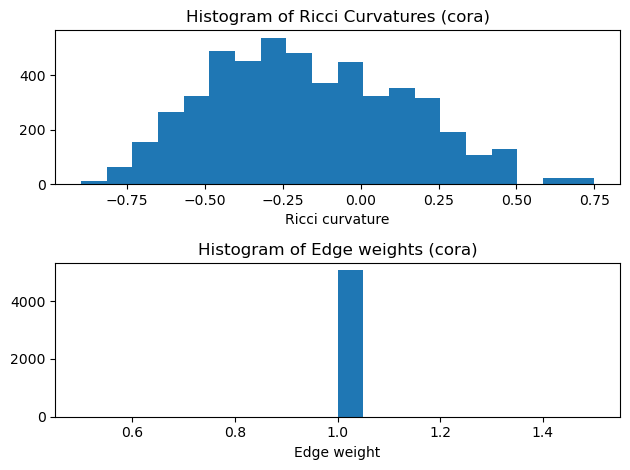

In [9]:
# compute orc on updated graph
Multiorc = MultiOllivierRicci(cora, alpha=0.5, verbose="INFO")
Multiorc.compute_ricci_curvature()
my_multi = Multiorc.G.copy()  # save an intermediate result
show_results(my_multi)